In [1]:
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
from ipywidgets import interact

import pickle

In [2]:
with open("hotels.pk", "rb") as f:
    df = pickle.load(f)


In [3]:
df.head()

,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,NewYork,2.442363e+06,13063.675000,81.991307
2013-01-02,NewYork,2.018559e+06,13069.608539,82.028548
2013-01-03,NewYork,1.927676e+06,13069.608539,82.028548
2013-01-04,NewYork,1.781664e+06,12653.271887,79.415502
2013-01-05,NewYork,1.824994e+06,12827.322364,80.507892


In [4]:
df['Location'].unique()

array(['NewYork', 'Orlando', 'Chicago', 'LosAngeles', 'Washington',
       'Atlanta', 'Dallas', 'Boston'], dtype=object)

In [7]:
def visualize_data(df, city, window=30):
    """
    Visualize revenue, demand, and occupancy for a given city with a time slider.
    Works whether 'Date' is a column or an index.
    """

    # Handle Date being either a column or an index
    if 'Date' in df.columns:
        df = df.copy()
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        df = df.copy()
        df = df.reset_index().rename(columns={'index': 'Date'})
        df['Date'] = pd.to_datetime(df['Date'])

    # Filter for the selected city
    if 'Location' not in df.columns:
        raise ValueError("The dataset must include a 'Location' column.")
    
    city_df = df[df['Location'] == city].sort_values('Date').reset_index(drop=True)
    
    if city_df.empty:
        raise ValueError(f"No data found for city '{city}'.")

    # Define slider
    slider = widgets.IntSlider(
        min=0,
        max=max(0, len(city_df) - window),
        step=1,
        value=0,
        description='Start Index:'
    )

    def update_plot(start):
        subset = city_df.iloc[start:start + window]

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=subset['Date'], y=subset['Revenue'], mode='lines+markers', name='Revenue'))
        fig.add_trace(go.Scatter(x=subset['Date'], y=subset['Demand'], mode='lines+markers', name='Demand'))
        fig.add_trace(go.Scatter(x=subset['Date'], y=subset['Occupancy'], mode='lines+markers', name='Occupancy'))

        fig.update_layout(
            title=f'{city} — Performance Over Time (Days {start}–{start+window})',
            xaxis_title='Date',
            yaxis_title='Value',
            hovermode='x unified',
            template='plotly_dark',
            height=500,
        )
        fig.show()

    interact(update_plot, start=slider)

In [8]:
visualize_data(df, city='Boston', window=30)

interactive(children=(IntSlider(value=0, description='Start Index:', max=2831), Output()), _dom_classes=('widg…

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def outlier_detector(df, n_sigma=3.):
    """
    Detect outliers using persistence-based forecasting (shift(1)).
    Identifies points where prediction error exceeds n_sigma*std.
    If consecutive outliers are found, keeps only the first one.
    
    Parameters
    ----------
    df : pd.Series or pd.DataFrame (single column)
        Time series data to analyze.
    n_sigma : float, optional
        Number of standard deviations threshold. Default is 3.
        
    Returns
    -------
    is_outlier : np.ndarray
        Array of indices where outliers occur.
    """
    # forecaster: persistent
    preds = df.shift(1)

    # find err std, candidate outliers have error > n_sigma*sigma
    err = preds - df
    sigma = err.std()
    candidates = np.argwhere((err.abs() > sigma*n_sigma).values).ravel()

    pd.DataFrame(err.abs().sort_values().values[:-1], index=np.linspace(0, 1, len(err)-1)).plot()

    # if candidate outliers are consecutive, keep only the first
    is_outlier = []
    for i, c in enumerate(candidates):
        if i == 0 or candidates[i-1] != c-1:
            is_outlier.append(c)
    is_outlier = np.array(is_outlier)

    # do nice plots
    fig, ax = plt.subplots(2, 1, figsize=(12, 5))
    err.hist(bins=200, ax=ax[0])
    ax[0].set_title('Error Distribution')
    ax[0].set_xlabel('Prediction Error')
    
    preds.plot(ax=ax[1], label='Predictions (shifted)', alpha=0.7)
    df.plot(ax=ax[1], label='Actual Data')
    if len(is_outlier) > 0:
        ax[1].plot(df.index[is_outlier], df.iloc[is_outlier].values, 'r.', markersize=10, label='Outliers')
    ax[1].set_title('Data with Outliers Highlighted')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return is_outlier


In [19]:
CITY = "Boston"
df_city = df[df['Location'] == CITY].copy()

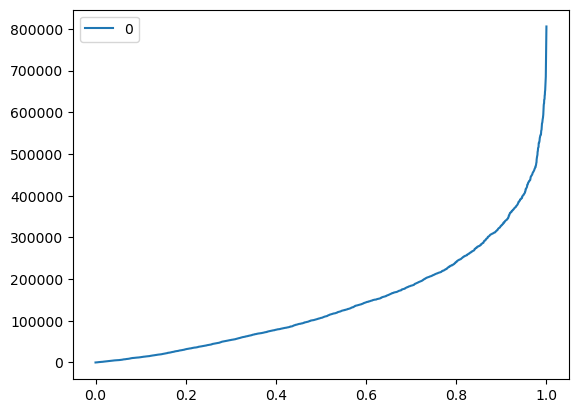

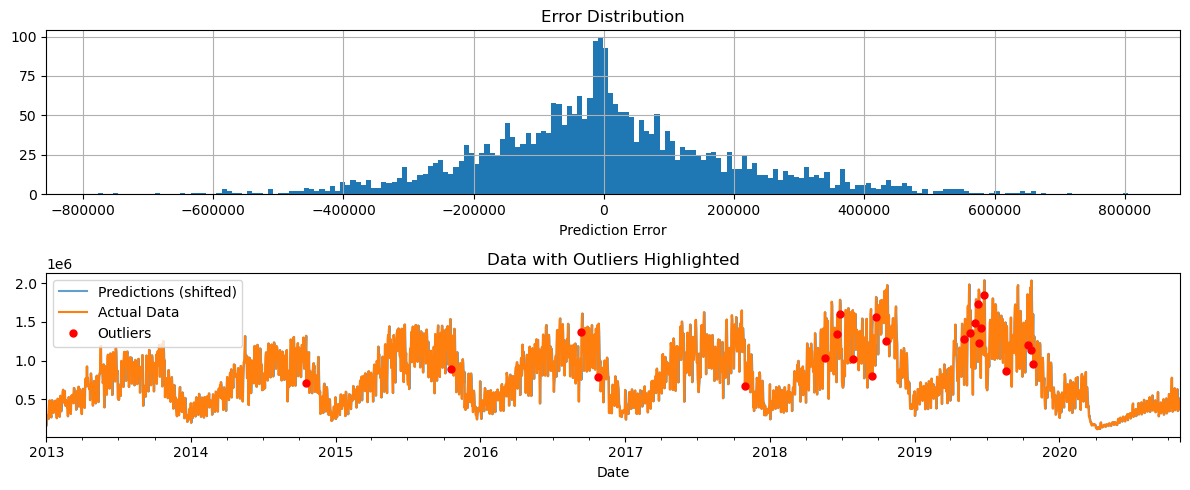

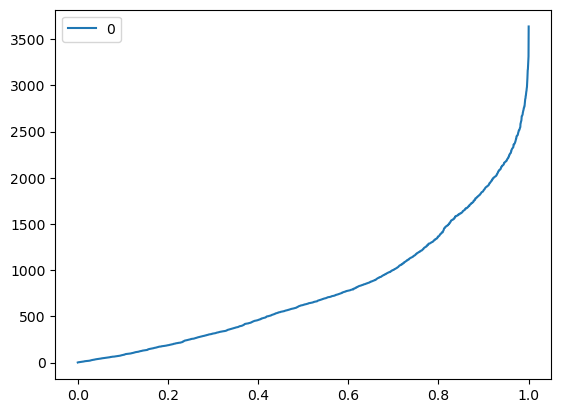

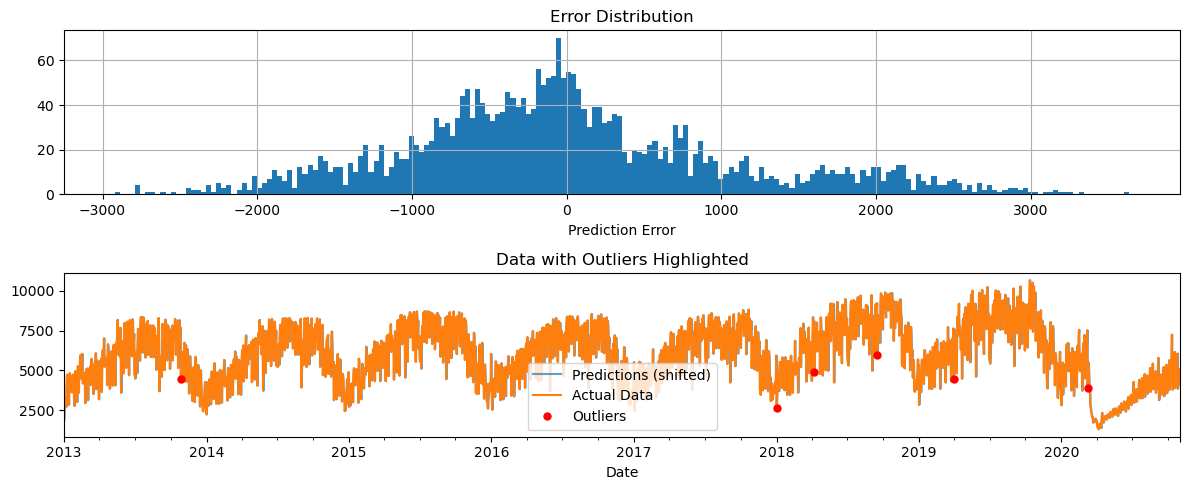

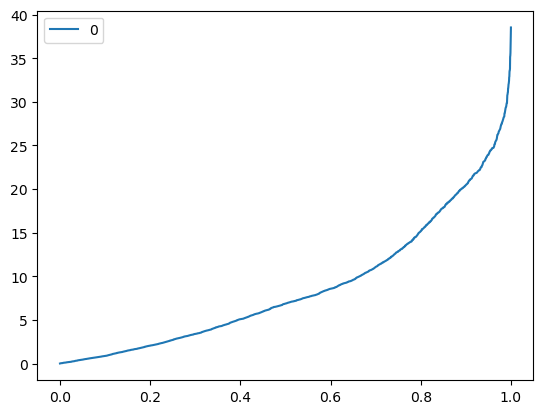

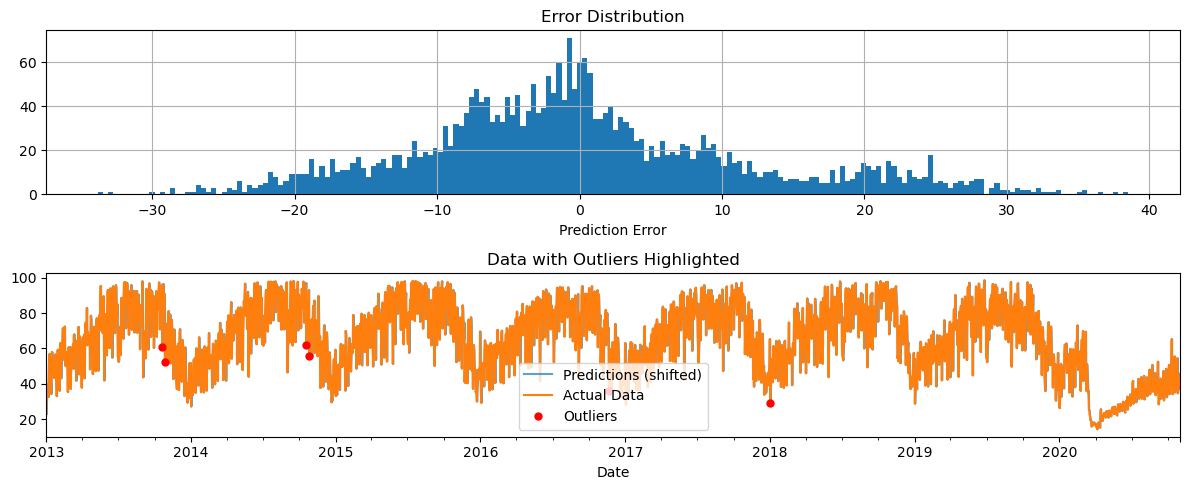

In [20]:
# Check outliers in Revenue
outlier_revenue = outlier_detector(df_city['Revenue'])

# Check outliers in Demand
outlier_demand = outlier_detector(df_city['Demand'])

# Check outliers in Occupancy
outlier_occupancy = outlier_detector(df_city['Occupancy'])


In [21]:
def visualize_outliers_with_slider(df_city, outlier_indices, column='Revenue', window=30):
    """
    Visualize time series data with outliers highlighted using a time slider.
    
    Parameters
    ----------
    df_city : pd.DataFrame
        Filtered dataframe for a single city
    outlier_indices : np.ndarray
        Array of indices where outliers occur (from outlier_detector)
    column : str
        Column name to visualize
    window : int
        Number of data points to show in the window
    """
    import plotly.graph_objects as go
    from ipywidgets import interact, IntSlider
    
    # Ensure we have a proper index
    df_plot = df_city.reset_index(drop=True).copy()
    
    # Create a boolean mask for outliers
    outlier_mask = np.zeros(len(df_plot), dtype=bool)
    outlier_mask[outlier_indices] = True
    
    # Define slider
    slider = IntSlider(
        min=0,
        max=max(0, len(df_plot) - window),
        step=1,
        value=0,
        description='Start Index:'
    )
    
    def update_plot(start):
        subset = df_plot.iloc[start:start + window]
        outlier_subset = outlier_mask[start:start + window]
        
        fig = go.Figure()
        
        # Plot all data points
        fig.add_trace(go.Scatter(
            x=subset.index,
            y=subset[column],
            mode='lines+markers',
            name=column,
            line=dict(color='lightblue'),
            marker=dict(size=6)
        ))
        
        # Highlight outliers
        outlier_data = subset[outlier_subset]
        if len(outlier_data) > 0:
            fig.add_trace(go.Scatter(
                x=outlier_data.index,
                y=outlier_data[column],
                mode='markers',
                name='Outliers',
                marker=dict(color='red', size=12, symbol='x', line=dict(width=2))
            ))
        
        fig.update_layout(
            title=f'{column} with Outliers — Window {start} to {start+window}',
            xaxis_title='Index',
            yaxis_title=column,
            hovermode='x unified',
            template='plotly_dark',
            height=500,
        )
        fig.show()
    
    interact(update_plot, start=slider)

In [22]:
# Visualize Revenue outliers with slider
visualize_outliers_with_slider(df_city, outlier_revenue, column='Revenue', window=50)

interactive(children=(IntSlider(value=0, description='Start Index:', max=2811), Output()), _dom_classes=('widg…